# ExtractFeature,StackModel

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/no-cwt-dataset/X_1.csv
/kaggle/input/no-cwt-dataset/X_3.csv
/kaggle/input/no-cwt-dataset/X_2.csv
/kaggle/input/no-cwt-dataset/X_4.csv
/kaggle/input/no-cwt-dataset/X_5.csv
/kaggle/input/fft-features/Person_4.csv
/kaggle/input/fft-features/Person_2.csv
/kaggle/input/fft-features/Person_1.csv
/kaggle/input/fft-features/Person_3.csv
/kaggle/input/fft-features/Person_5.csv
/kaggle/input/eeg-data/subject_6.csv
/kaggle/input/eeg-data/subject_20.csv
/kaggle/input/eeg-data/subject_21.csv
/kaggle/input/eeg-data/subject_19.csv
/kaggle/input/eeg-data/subject_7.csv
/kaggle/input/eeg-data/subject_28.csv
/kaggle/input/eeg-data/subject_3.csv
/kaggle/input/eeg-data/subject_17.csv
/kaggle/input/eeg-data/subject_13.csv
/kaggle/input/eeg-data/subject_31.csv
/kaggle/input/eeg-data/subject_14.csv
/kaggle/input/eeg-data/subject_34.csv
/kaggle/input/eeg-data/subject_4.csv
/kaggle/input/eeg-data/subject_33.csv
/kaggle/input/eeg-data/subject_25.csv
/kaggle/input/eeg-data/subject_26.csv
/kaggle/inp

In [ ]:
import seaborn as sns
import pywt
import scipy
from joblib import Parallel, delayed
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from numpy.fft import rfft, rfftfreq
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

## Using Fourier Transform to process data

### Necessary function

In [ ]:
def get_fft(snippet, sampling_rate=128.0):
    """
    Calculates FFT (Fast Fourier Transform) and returns frequency (frq) and spectrum amplitude (magnitude).

    Parameters:
    - snippet: Input signal (1D array).
    - sampling_rate: Sampling frequency (Hz), default is 128 Hz.

    Returns:
    - frq: Frequency array (Hz).
    - magnitude: Corresponding spectrum amplitude.
    """
    n = len(snippet)

    k = np.arange(n)
    T = n / sampling_rate
    frq = k / T
    frq = frq[:n // 2]

    Y = np.fft.fft(snippet) / n
    magnitude = np.abs(Y[:n // 2])

    magnitude[0] = 0

    return frq, magnitude

def waves_averages(f,Y):
    """
    Compute the sum of magnitudes for specific brainwave frequency bands.

    Parameters:
    - f (array-like): Frequencies corresponding to the input frequency-domain signal `Y`.
    - Y (array-like): The frequency-domain signal (e.g., FFT magnitudes).

    Returns:
    - gamma (float): Sum of magnitudes in the gamma wave range (32 - 100 Hz).
    - alpha (float): Sum of magnitudes in the alpha wave range (8 - 13 Hz).
    - beta (float): Sum of magnitudes in the beta wave range (16 - 31 Hz).
    - theta (float): Sum of magnitudes in the theta wave range (4 - 7 Hz).
    - delta (float): Sum of magnitudes in the delta wave range (0.2 - 3 Hz).
    """
    theta_range = (4,7)
    alpha_range = (8,13)
    beta_range = (16,31)
    gamma_range=(32,100)
    delta_range=(0.2,3)
    theta = np.abs(Y[(f>theta_range[0]) & (f<=theta_range[1])]).sum(axis=0)
    alpha = np.abs(Y[(f>alpha_range[0]) & (f<=alpha_range[1])]).sum(axis=0)
    beta = np.abs(Y[(f>beta_range[0]) & (f<=beta_range[1])]).sum(axis=0)
    gamma=np.abs(Y[(f>gamma_range[0]) & (f<=gamma_range[1])]).sum(axis=0)
    delta=np.abs(Y[(f>delta_range[0]) & (f<=delta_range[1])]).sum(axis=0)
    return gamma,alpha,beta,theta,delta

In [ ]:
def make_steps(samples,frame_duration,overlap):
    """
    Generate overlapping frame intervals for signal processing.

    Parameters:
    - samples (int): Total number of samples in the session.
    - frame_duration (int): Duration of each frame in seconds.
    - overlap (float): Fraction of overlap between consecutive frames,
      should be in the range (0, 1).
      Example: overlap=0.5 means 50% overlap.

    """
    Fs = 128
    i = 0
    intervals = []
    samples_per_frame = Fs * frame_duration
    while i+samples_per_frame <= samples:
        intervals.append((i,i+samples_per_frame))
        i = i + samples_per_frame - int(samples_per_frame*overlap)
    return intervals

def calculate_cwt(samples, scales=np.arange(1,9), wavelet='morl'):
    """
    Calculate the Continuous Wavelet Transform (CWT) for a given signal.
    Parameters:
    - samples (array-like): The 1D input signal for which the CWT is computed.
    - scales (array-like, optional): An array of scales to use for the wavelet transform.
      - Default is np.arange(1, 9), which corresponds to scales 1 through 8.
      - Smaller scales correspond to higher frequencies, and larger scales correspond to lower frequencies.
    - wavelet (str, optional): The type of wavelet to use for the transform.
      - Default is 'morl', which is the Morlet wavelet, commonly used in signal processing.

    Returns:
    - coeffs_abs (2D array): The absolute values of the wavelet coefficients.
      - Shape: (len(scales), len(samples)).
      - Each row corresponds to a scale, and each column corresponds to a time point in the signal.
    """
    coeffs, freqs = pywt.cwt(samples, scales, wavelet)
    coeffs_abs = np.abs(coeffs)
    return coeffs_abs

def make_frames(df, frame_duration, overlap,Fs = 128.0):
    '''
    Parameters:
    -  dataframe or array with all channels
    -  frame duration in seconds
    '''
    frame_length = int(Fs * frame_duration)
    frames = []
    steps = make_steps(len(df), frame_duration, overlap)
    frq = None

    for step_idx, step in enumerate(steps):
        frame = []
        for channel_idx, channel in enumerate(df.columns):
            snippet = np.array(df.loc[step[0]:step[1]-1, channel])
            f, Y = get_fft(snippet)
            if frq is not None:
                frq = np.concatenate((frq, f), axis=0)
            else:
                frq = f

            #Split into signal bands
            alpha, beta, gamma, theta, delta = waves_averages(f, Y)
            frame.extend([alpha, beta, theta, delta])

            # Statistic features
            mean = np.mean(snippet)
            variance = np.var(snippet)
            std = np.std(snippet)
            energy = np.sum(snippet**2)
            skewness = skew(snippet)
            excess_kurtosis = kurtosis(snippet)
            frame.extend([mean,variance, std, energy, skewness, excess_kurtosis])

            #Spectral features
            psd = Y**2
            psd_mean=np.mean(psd)
            psd_norm = psd/np.sum(psd)
            entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
            frame.extend([psd_mean, entropy])

            #Time-Frequency features
            cwtmatr = calculate_cwt(snippet)
            cwt_means = cwtmatr.mean(axis=1)
            frame.extend(cwt_means)

        frames.append(frame)

    feature_columns = []
    for channel in df.columns:
        feature_columns.extend([
            f'{channel}_alpha', f'{channel}_beta', f'{channel}_theta',
            f'{channel}_delta', f'{channel}_mean', f'{channel}_variance',
            f'{channel}_std', f'{channel}_energy', f'{channel}_skewness',
            f'{channel}_kurtosis', f'{channel}_psd', f'{channel}_entropy'
        ])
        for i in range(1, 9):
            feature_columns.append(f'{channel}_cwt_scale_{i}')
    feature_df = pd.DataFrame(frames, columns=feature_columns)
    return feature_df, frq

In [ ]:
def plot_fft(df, start_time, frame_duration=None, Fs=128):
    """
    Plots frequency vs EEG power (for FFT) or frequency vs PSD (for Welch) for given EEG channels.

    Parameters:
    eeg_data (pandas.DataFrame): EEG data DataFrame
    channels (list): List of channel names to analyze
    start_time (float): Start time of the analysis in seconds
    duration (float, optional): Duration of the analysis in seconds. If None, analyzes until the end of the data.
    sampling_rate (int): Sampling rate of the EEG data in Hz (default is 128 Hz)
    method (str): Method for analysis ('fft' for Power or 'welch' for PSD)
    """
    first_index = int(start_time * Fs)
    if frame_duration is None:
        last_index = len(df)
    else:
        last_index = int((start_time + frame_duration) * Fs)

    n_channels = len(df.columns)
    n_rows = (n_channels + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(20, 5 * n_rows))

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for channel_idx, channel in enumerate(df.columns):
        row = channel_idx // 2
        col = channel_idx % 2
        ax = axes[row, col]

        channel_data = df[channel].values[first_index:last_index]


        n = len(channel_data)
        snippet = np.array(df.loc[first_index:last_index, channel])
        f, Y = get_fft(snippet)

        power = np.abs(Y) ** 2

        ax.plot(f, power, label='Power')
        ax.set_title(f'{channel} - FFT for EEG signals')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Power')

        ax.grid(True)

    for i in range(len(df.columns), n_rows * 2):
        row = i // 2
        col = i % 2
        fig.delaxes(axes[row, col])

    plt.tight_layout()
    plt.show()


def plot_single_channel_bands(df, channel, time_points, frame_duration=10, Fs=128):
    """
    Plots frequency vs EEG power (for FFT) for a single EEG channel at specified time points in a single row.

    Parameters:
    df (pandas.DataFrame): EEG data DataFrame
    channel (str): The channel name to analyze
    time_points (list): List of time points (in seconds) for plotting
    frame_duration (float): Duration of each analysis window in seconds (default is 10s)
    Fs (int): Sampling rate of the EEG data in Hz (default is 128 Hz)
    """
    bands = {
        'Delta': (0.5, 4),
        'Theta': (4, 8),
        'Alpha': (8, 13),
        'Beta': (13, 30),
        'Gamma': (30, 50)
    }
    colors = ["blue", "green", "orange", "red", "purple"]

    n_time_points = len(time_points)

    fig, axes = plt.subplots(1, n_time_points, figsize=(5 * n_time_points, 5), sharey=True)

    if n_time_points == 1:
        axes = [axes]

    for i, (ax, start_time) in enumerate(zip(axes, time_points)):
        first_index = int(start_time * Fs)
        last_index = int((start_time + frame_duration) * Fs)

        snippet = df[channel].iloc[first_index:last_index].values

        f, Y = get_fft(snippet, sampling_rate=Fs)
        power = np.abs(Y) ** 2  # Power spectrum

        ax.plot(f, power, label='Power Spectrum')
        if (start_time<=600):
            ax.set_title(f'{channel} at Focus State')
        elif (600<start_time<=1200):
            ax.set_title(f'{channel} at Unfocus State')
        else:
            ax.set_title(f'{channel} at Drowsy State')
        ax.set_xlabel('Frequency (Hz)')
        if i == 0:
            ax.set_ylabel('Power')
        ax.grid(True)

        for j, (band, (low, high)) in enumerate(bands.items()):
            ax.axvspan(low, high, color=colors[j], alpha=0.3, label=f"{band}")

        if i == len(time_points) - 1:
            ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_bands(df, start_time, frame_duration=None, Fs=128):
    """
    Plots frequency vs EEG power (for FFT) for given EEG channels.

    Parameters:
    df (pandas.DataFrame): EEG data DataFrame
    start_time (float): Start time of the analysis in seconds
    frame_duration (float, optional): Duration of the analysis in seconds. If None, analyzes until the end of the data.
    Fs (int): Sampling rate of the EEG data in Hz (default is 128 Hz)
    """
    first_index = int(start_time * Fs)
    if frame_duration is None:
        last_index = len(df)
    else:
        last_index = int((start_time + frame_duration) * Fs)

    n_channels = len(df.columns)
    n_rows = (n_channels + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(20, 5 * n_rows))

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    bands = {
        'Delta': (0.5, 4),
        'Theta': (4, 8),
        'Alpha': (8, 13),
        'Beta': (13, 30),
        'Gamma': (30, 50)
    }
    colors = ["blue", "green", "orange", "red", "purple"]

    for channel_idx, channel in enumerate(df.columns):
        row = channel_idx // 2
        col = channel_idx % 2
        ax = axes[row, col]

        snippet = df[channel].iloc[first_index:last_index].values

        f, Y = get_fft(snippet, sampling_rate=Fs)
        power = np.abs(Y) ** 2

        ax.plot(f, power, label='Power Spectrum')
        ax.set_title(f'{channel} - Frequency vs Power (FFT)')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Power')
        ax.grid(True)

        for i, (band, (low, high)) in enumerate(bands.items()):
            ax.axvspan(low, high, color=colors[i], alpha=0.3, label=f"{band}")

        ax.legend(loc='upper right')

    for i in range(len(df.columns), n_rows * 2):
        row = i // 2
        col = i % 2
        fig.delaxes(axes[row, col])

    plt.tight_layout()
    plt.show()

In [ ]:
def normalize_positions(positions):
    """
    Normalize the positions of EEG channels to fit within a unit circle.

    Parameters:
    positions (dict): A dictionary of channel positions with channel names as keys
                      and (x, y) coordinates as values.

    """
    max_radius = max(np.sqrt(x**2 + y**2) for x, y in positions.values())
    return {key: (x / max_radius, y / max_radius) for key, (x, y) in positions.items()}

def plot_eeg_channels(channel_locations):
    """
    Plots the normalized positions of EEG channels on a 2D head map.

    Parameters:
    channel_locations (dict): A dictionary with channel names as keys and (x, y) positions as values.
    """
    normalized_locations = normalize_positions(channel_locations)

    fig, ax = plt.subplots(figsize=(6, 6))

    head_circle = plt.Circle((0, 0), 1, color='black', fill=False, lw=2)
    ax.add_artist(head_circle)

    for channel, (x, y) in normalized_locations.items():
        ax.plot(x, y, 'o', color='blue')
        ax.text(x, y + 0.1, channel, fontsize=10, ha='center', color='green')  # Label channel

    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_aspect('equal', adjustable='datalim')
    ax.axis('off')
    plt.title("EEG Channel Positions")
    plt.show()



In [ ]:
def plot_label_distribution(subject_y):
    """
    Plots the label distribution as a bar chart.

    Parameters:
    subject_y (pandas.Series): The column containing the labels (e.g., 'state').
    """
    label_counts = subject_y.value_counts()

    plt.figure(figsize=(10, 6))
    label_counts.plot(kind='bar', color='skyblue', edgecolor='black')

    plt.title('Label Distribution', fontsize=16)
    plt.xlabel('Labels', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xticks(rotation=0, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_confusion_matrix(cm, labels):
    """
    Plot a confusion matrix as a heatmap for easy visualization and interpretation.

    Parameters:
    - cm (2D array or DataFrame): The confusion matrix to be visualized,
      typically generated using sklearn's confusion_matrix function.
    - labels (list): A list of class labels corresponding to the rows and columns
      of the confusion matrix. Used as tick labels on the axes.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
def plot_multiclass_roc(y_true, y_scores, n_classes):
    """
    Computes and plots ROC curves and AUC scores for multi-class classification.

    Parameters:
    - y_true: array-like, shape (n_samples,)
        True labels of the test set (not one-hot encoded).
    - y_scores: array-like, shape (n_samples, n_classes)
        Predicted probabilities for each class.
    - n_classes: int
        The number of classes in the dataset.

    """
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    # Initialize dictionaries to store FPR, TPR, and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}

    # Compute ROC curve and AUC for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot the ROC curves
    plt.figure(figsize=(8, 5))
    colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink']  # Extendable for more classes
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)], lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=2,
             label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=1.5, label='Random Guessing')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Multi-Class Classification')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

### Data Loaded and EDA

In [ ]:
df=pd.read_csv('/kaggle/input/eeg-data/subject_27.csv')
features=df.drop(columns=['state','AF3','AF4'])

The electrode locations for different brain wave channels are illustrated in the image below:

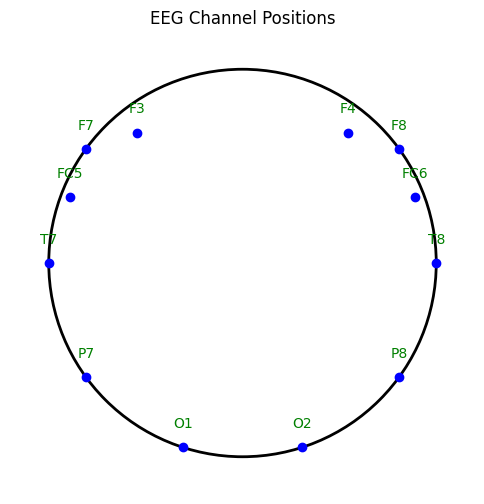

In [ ]:
channel_locations = {
    'F7': [-0.0768098, 0.05580558],
    'F3': [-0.05177571, 0.06393767],
    'FC5': [-0.08434934, 0.03237868],
    'T7': [-0.09494213, 0.0],
    'P7': [-0.0768098, -0.05580558],
    'O1': [-0.02933873, -0.09029533],
    'O2': [0.02933873, -0.09029533],
    'P8': [0.0768098, -0.05580558],
    'T8': [0.09494213, 0.0],
    'FC6': [0.08434934, 0.03237868],
    'F4': [0.05177571, 0.06393767],
    'F8': [0.0768098, 0.05580558]
}

plot_eeg_channels(channel_locations)


The graphs below illustrate the distribution of brain waves across frequency bands for each channel. The graph is at 300 seconds (5 minutes). It can be seen that in most channels, the waves belong to the beta and gamma frequency bands. This is true for the state of concentration. However, there are some channels that show more noise because they are more susceptible to external influences (O1, O2, P7, P8).

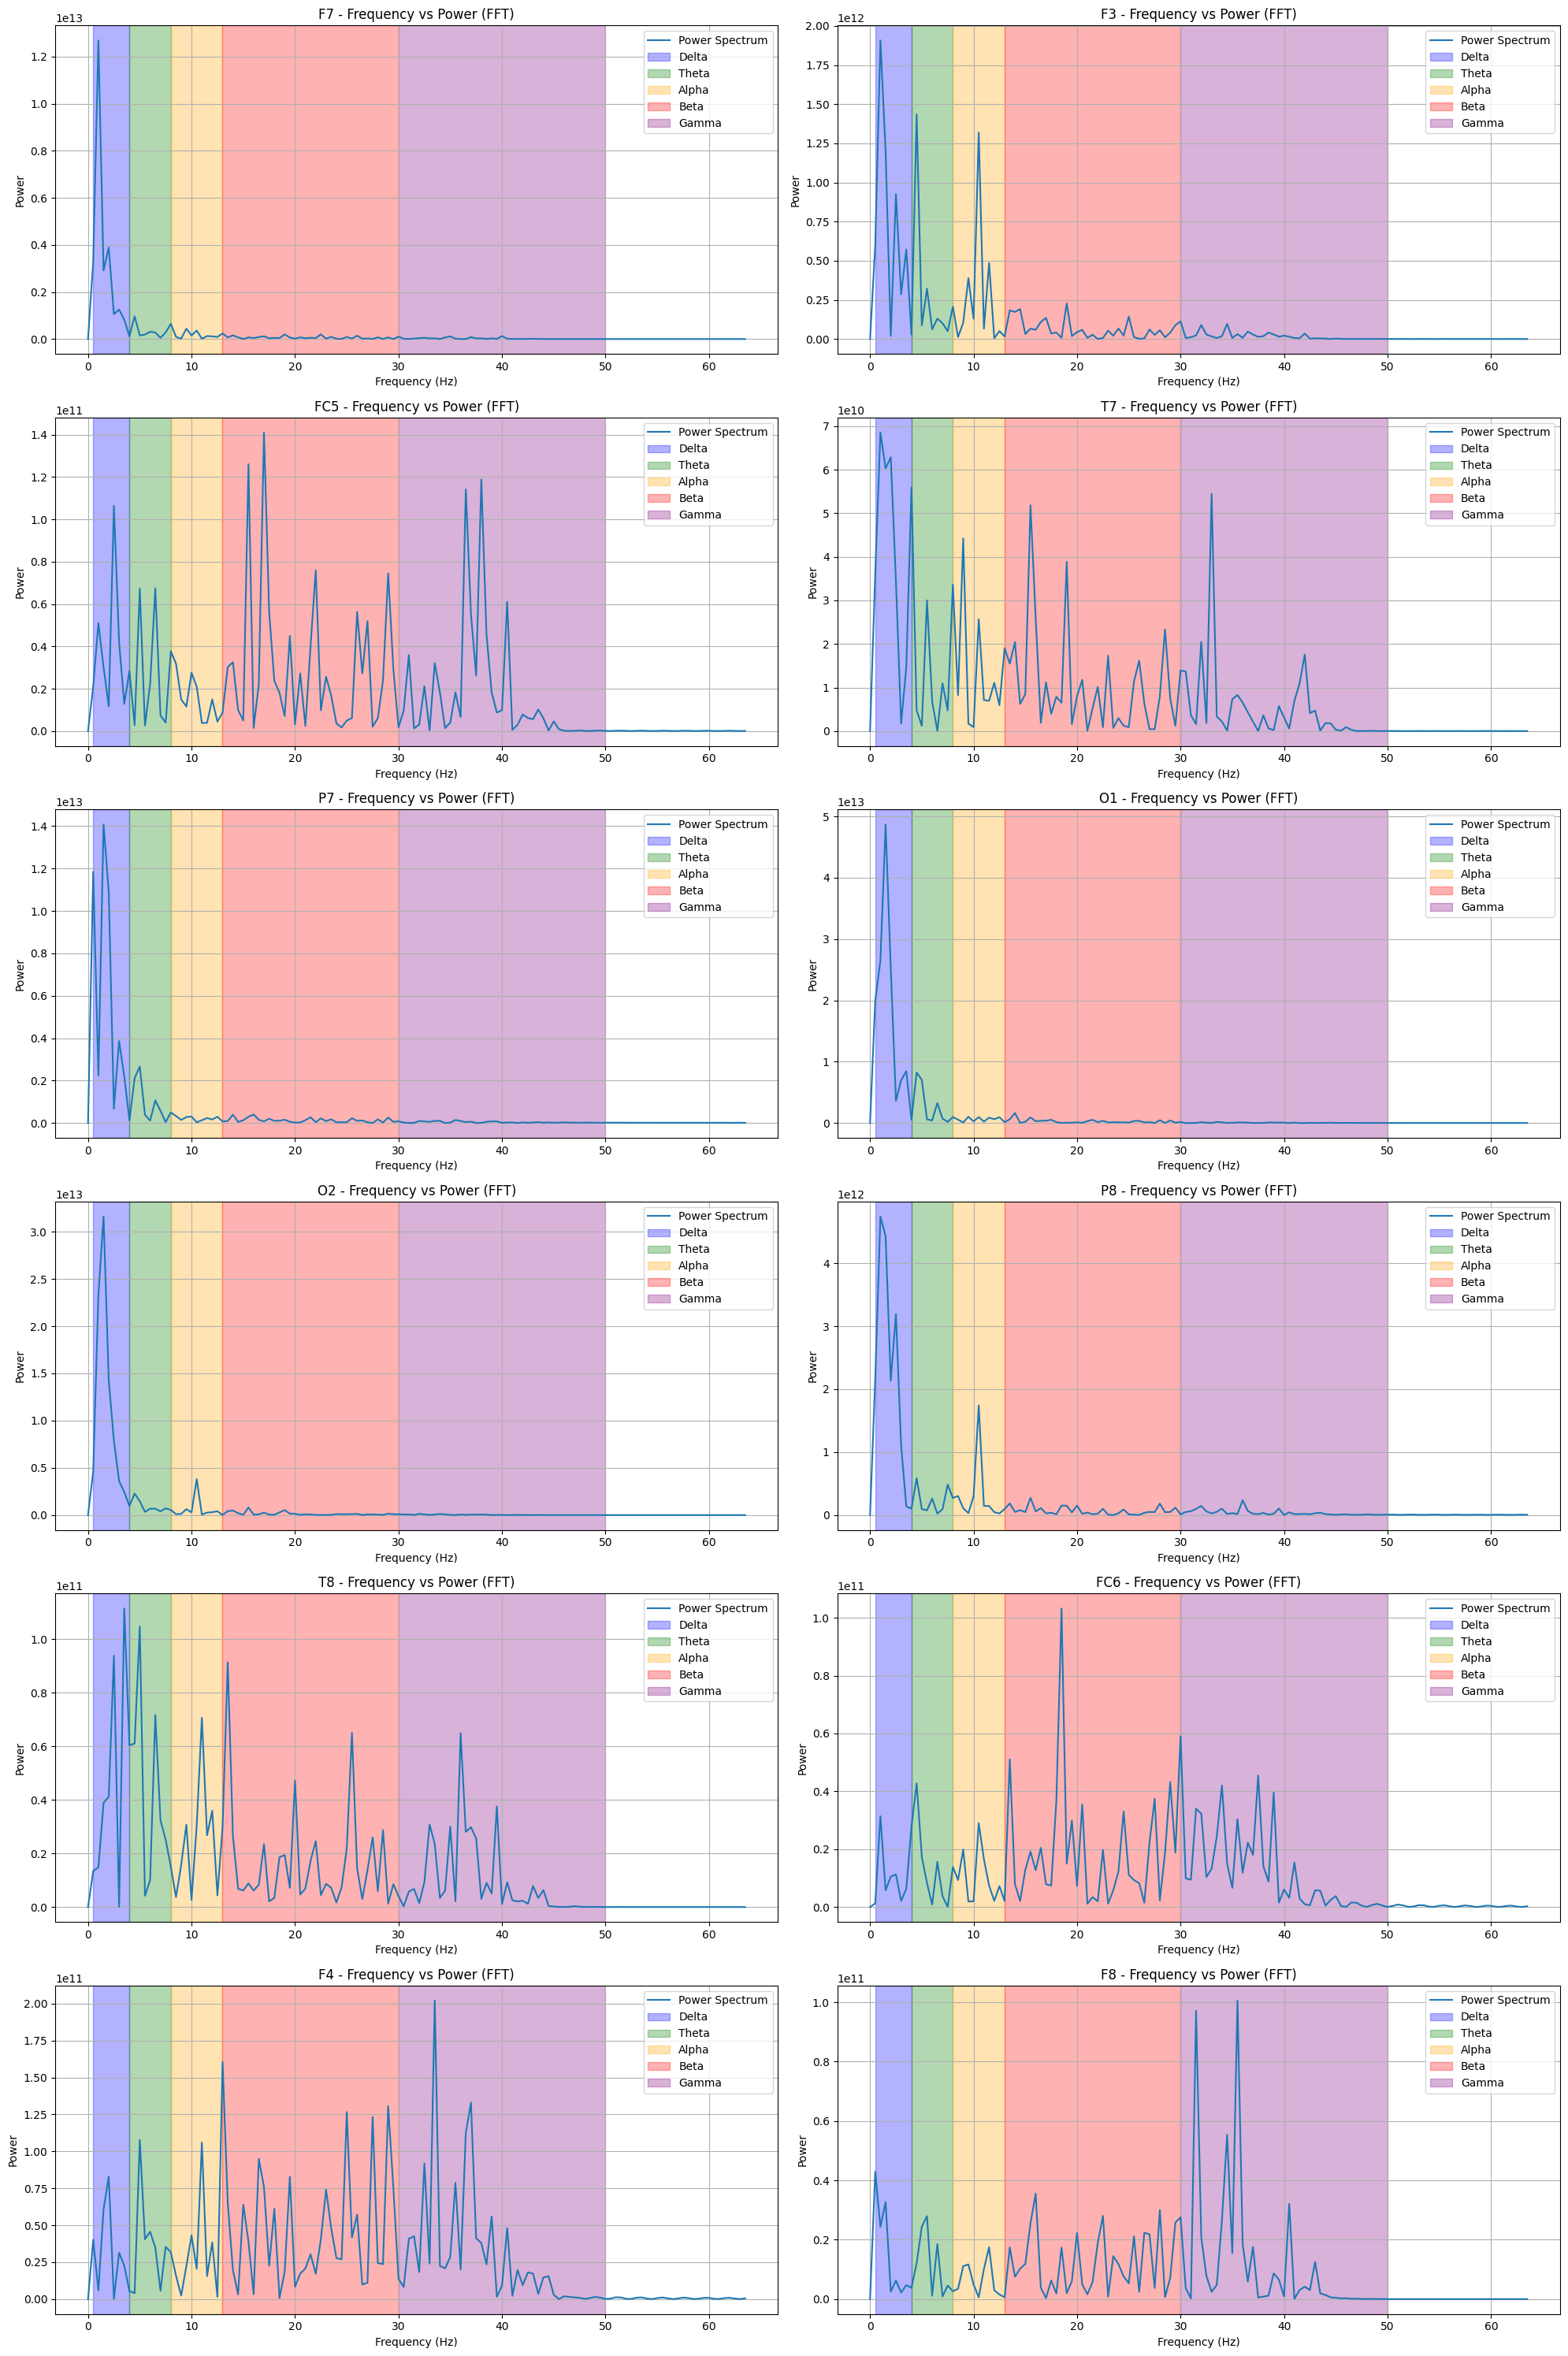

In [ ]:
plot_bands(features,300,2)

We analyze the waves in the FC5 channel in 3 states: Focus, Unfocus and Drowsy. It can be seen that in the focus state, the waves are concentrated in the beta and gamma bands, in the unfocus state, the waves are concentrated in the alpha band and in the drowsy state, the waves are concentrated in the delta band.

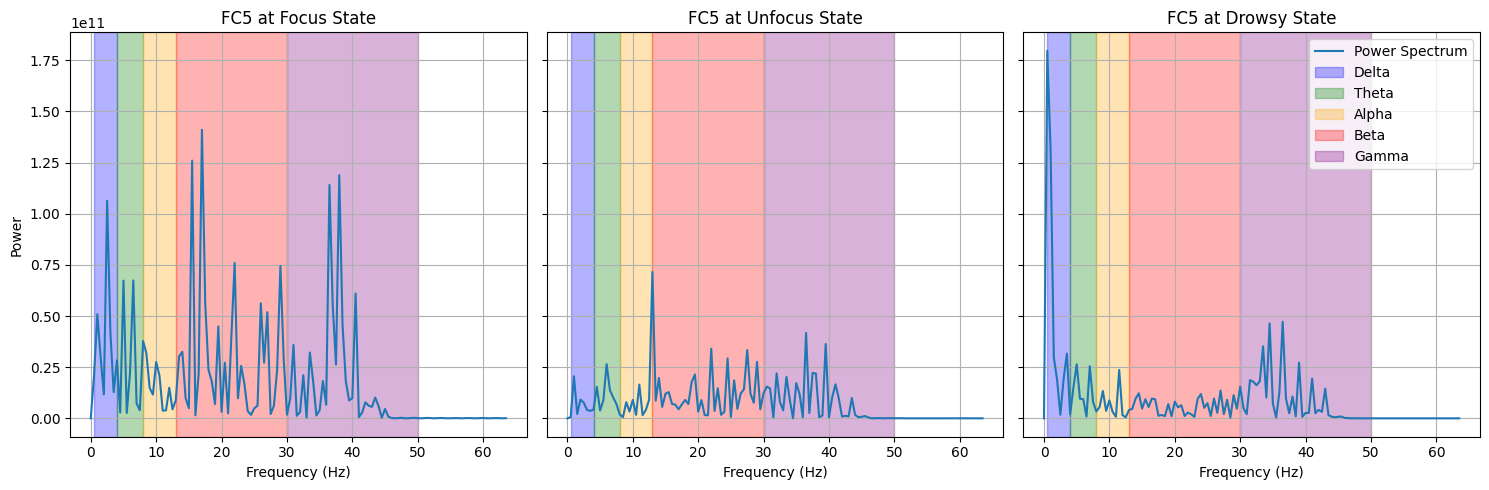

In [ ]:
time_points = [300, 900, 1800]

plot_single_channel_bands(features, "FC5", time_points, frame_duration=2)

From this factor, we can choose the wave frequency band as a characteristic to distinguish the 3 states from each other. In addition, we can add statistical features of the waves to enrich the data set.

### Classification by using fft and adding features

#### Loaded Data

In [ ]:
p1=pd.read_csv('/kaggle/input/no-cwt-dataset/X_1.csv')
p2=pd.read_csv('/kaggle/input/no-cwt-dataset/X_2.csv')
p3=pd.read_csv('/kaggle/input/no-cwt-dataset/X_3.csv')
p4=pd.read_csv('/kaggle/input/no-cwt-dataset/X_4.csv')
p5=pd.read_csv('/kaggle/input/no-cwt-dataset/X_5.csv')

dataset=pd.concat([p1,p2,p3,p4,p5], ignore_index=True)
dataset.drop(columns=['Unnamed: 0'],inplace=True)

#### Transforming EEG data set by using FFT and adding features

In [ ]:
# all_data=[]
# for i in range (31,35):
#         df=pd.read_csv(f'/kaggle/input/eeg-data/subject_{i}.csv')
#         print(f'subject_{i}')
#         df=df.drop(columns=['AF3','AF4'])
#         state_encode = {
#                 1: 0,
#                 2: 1,
#                 0: 2
#             }
#         df['state']=df['state'].map(state_encode)

#         df_focused = df[df['state'] == 0]
#         df_unfocused = df[df['state'] == 1].reset_index(drop=True)
#         df_drowsy = df[df['state'] == 2].reset_index(drop=True)

#         focused,focused_frq=make_frames(df_focused.drop(columns=['state']),1,0.3)
#         unfocused, unfocused_frq=make_frames(df_unfocused.drop(columns=['state']),1,0.3)
#         drowsy, drowsy_frq=make_frames(df_drowsy.drop(columns=['state']),1,0.3)

#         focused["state"] = 0
#         unfocused["state"] = 1
#         drowsy["state"] = 2
#         print('Length focused:',len(focused))
#         print('Length unfocused: ',len(unfocused))
#         print('Length drowsy: ',len(drowsy))
#         df_fft = pd.concat([focused, unfocused, drowsy])
#         all_data.append(df_fft)
# # Concatenate all DataFrames into one big DataFrame
# big_dataset = pd.concat(all_data, ignore_index=True)

# # Display or save the big dataset
# print('Length full dataset: ',len(big_dataset))
# big_dataset.to_csv('X_5.csv')

#### Features Engineering

In [ ]:
subject_X=dataset.drop(columns=['state'])
subject_y=dataset['state']

Through the data table and graph below, we can see that the data set is unbalanced due to

In [ ]:
num_y = subject_y.value_counts()
data = {
    'State': ['0', '1', '2'],
    'Count': [num_y[0], num_y[1], num_y[2]]
}

distribution = pd.DataFrame(data)

distribution['Percentage (%)'] = (distribution['Count'] / distribution['Count'].sum()) * 100

distribution


,State,Count,Percentage (%)
0,0,20448,26.549638
1,1,20387,26.470435
2,2,36183,46.979927


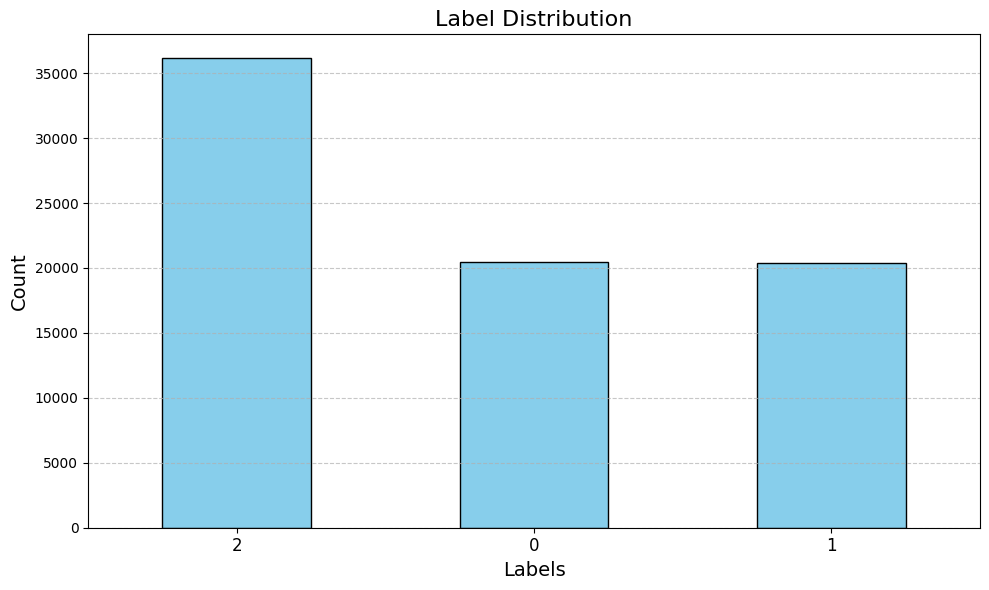

In [ ]:
plot_label_distribution(dataset['state'])

In [ ]:
print("Original class distribution:", Counter(subject_y))

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(subject_X, subject_y)

print("Resampled class distribution:", Counter(y_resampled))

Original class distribution: Counter({2: 36183, 0: 20448, 1: 20387})
Resampled class distribution: Counter({0: 20387, 1: 20387, 2: 20387})


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_X=scaler.fit_transform(X_resampled)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y_resampled, test_size=0.3, random_state=42)

Decision Tree
              precision    recall  f1-score   support

           0       0.71      0.69      0.70      6101
           1       0.61      0.63      0.62      6096
           2       0.72      0.71      0.71      6152

    accuracy                           0.68     18349
   macro avg       0.68      0.68      0.68     18349
weighted avg       0.68      0.68      0.68     18349

Micro-average AUC: 0.7578


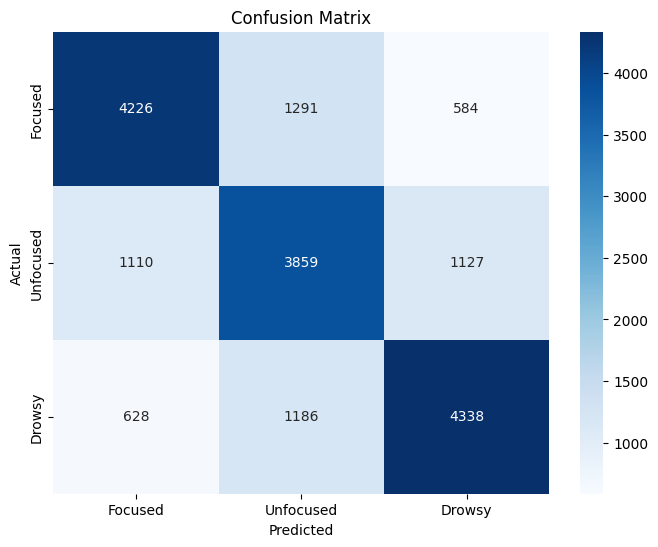

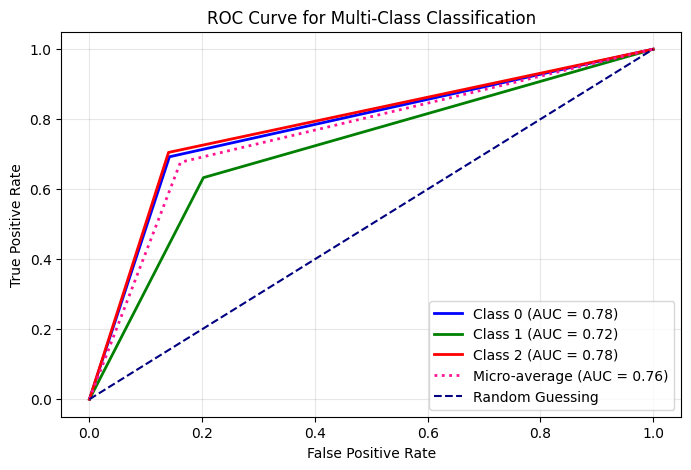

In [ ]:
dt_model = DecisionTreeClassifier(random_state=0)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

print("Decision Tree")
print(classification_report(y_test, dt_preds))

y_score =dt_model.predict_proba(X_test)
y_true_bin = label_binarize(y_test, classes=list(range(3)))
micro_auc = roc_auc_score(y_true_bin, y_score, average="micro")
print(f"Micro-average AUC: {micro_auc:.4f}")

cm = confusion_matrix(y_test, dt_preds)
plot_confusion_matrix(cm=cm, labels=['Focused', 'Unfocused', 'Drowsy'])


plot_multiclass_roc(y_test, y_score, n_classes=3)

K-Nearest Neighbour:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78      6101
           1       0.68      0.73      0.70      6096
           2       0.82      0.74      0.78      6152

    accuracy                           0.75     18349
   macro avg       0.76      0.75      0.76     18349
weighted avg       0.76      0.75      0.76     18349

Micro-average AUC: 0.9047


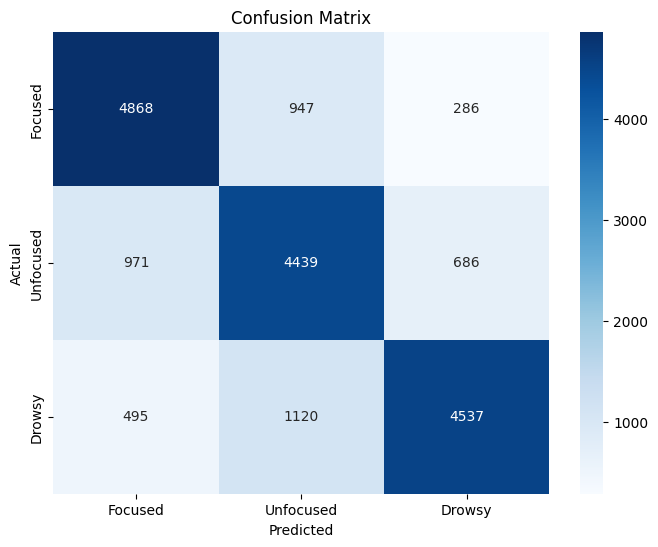

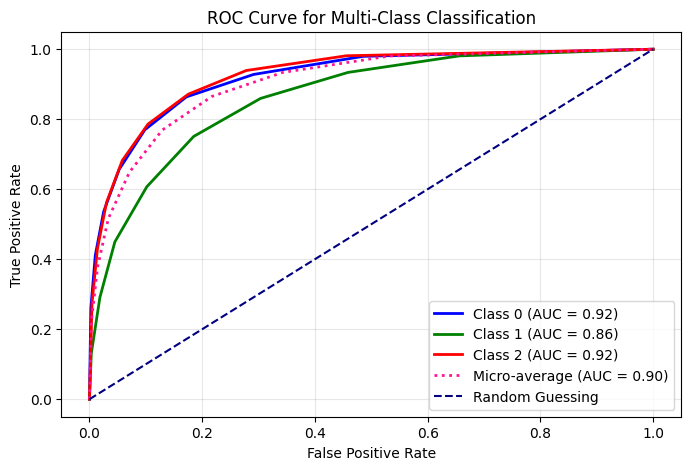

In [ ]:
# Using K-Nearest Neighbors to classification
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=8,
    weights='uniform',
    algorithm='auto'
)
knn.fit(X_train, y_train)
knn_pred=knn.predict(X_test)

print("K-Nearest Neighbour:")
print(classification_report(y_test,knn_pred))

y_score =knn.predict_proba(X_test)
y_true_bin = label_binarize(y_test, classes=list(range(3)))
micro_auc = roc_auc_score(y_true_bin, y_score, average="micro")
print(f"Micro-average AUC: {micro_auc:.4f}")

cm = confusion_matrix(y_test, knn_pred)
plot_confusion_matrix(cm=cm, labels=['Focused', 'Unfocused', 'Drowsy'])

plot_multiclass_roc(y_test, y_score, n_classes=3)

As can be seen from the models above, the classification is not really good, the labels are still confused with each other, making the performance of the model only average. To solve this problem, we will add features to increase the strength of the data set. Specifically in this report, we will use Continuous Wavelet Transform (CWT) to create new features.

## Continuous Wavelet Transform

Continuous Wavelet Transform is an analysis tool that takes a time-domain signal and returns the signal’s components in the frequency domain. However, in contrast to the Fourier Transform, the Continuous Wavelet Transform returns a two-dimensional result, providing information in the frequency- as well as in time-domain

### Necessary Function

In [ ]:
def plot_cwt_per_channel(df, scales, wavelet='morl', Fs=128, time_window=None):
    """
    Plots the Continuous Wavelet Transform (CWT) for each EEG channel.

    Parameters:
    df (pandas.DataFrame): The EEG data (with channels as columns)
    scales (np.array): Array of scales for the CWT
    wavelet (str): The wavelet function name
    Fs (int): Sampling rate (default is 128 Hz)
    time_window (tuple, optional): The start and end time for the window (in seconds).
                                    If None, it plots the entire signal.
    """
    time = np.linspace(0, len(df) / Fs, len(df))

    n_channels = len(df.columns)
    n_rows = (n_channels + 1) // 2
    fig, axs = plt.subplots(n_rows, 2, figsize=(12, 6 * n_rows))

    if n_rows == 1:
        axs = axs.reshape(1, -1)

    for channel_idx, channel in enumerate(df.columns):
        row = channel_idx // 2
        col = channel_idx % 2
        ax = axs[row, col]

        signal = df[channel].values

        # Calculate signal's components
        cwtmatr, freqs = pywt.cwt(signal, scales, wavelet, 1 / Fs)
        cwtmatr = np.abs(cwtmatr)

        pcm = ax.pcolormesh(time, freqs, cwtmatr, shading='auto')
        ax.set_yscale("log")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Frequency (Hz)")
        ax.set_title(f"CWT of {channel}")

        fig.colorbar(pcm, ax=ax)

    for i in range(len(df.columns), n_rows * 2):
        row = i // 2
        col = i % 2
        fig.delaxes(axs[row, col])

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_cwt_and_fft(signal, wavelet="morl", scales=np.arange(1, 9), Fs=128):
    """
    Perform Continuous Wavelet Transform (CWT) and Fourier Transform (FFT)
    on a signal and plot the results.

    Parameters:
    signal (array-like): Input signal for analysis.
    wavelet (str): The wavelet type for CWT (default is "morl").
    scales (array-like): Array of scales for the CWT (default is np.arange(1, 9)).
    Fs (int): Sampling frequency of the signal (default is 128 Hz).
    """
    time = np.linspace(0, len(signal) / Fs, len(signal))
    sampling_period = 1 / Fs

    cwtmatr, freqs = pywt.cwt(signal, scales, wavelet, sampling_period)
    cwtmatr = np.abs(cwtmatr)

    fig, axs = plt.subplots(2, 1, figsize=(8, 6))

    pcm = axs[0].pcolormesh(time, freqs, cwtmatr, shading="auto")
    axs[0].set_yscale("log")
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Frequency (Hz)")
    axs[0].set_title("Continuous Wavelet Transform (Scaleogram) on")
    fig.colorbar(pcm, ax=axs[0])

    yf = rfft(signal)
    xf = rfftfreq(len(signal), d=sampling_period)
    axs[1].semilogx(xf, np.abs(yf))
    axs[1].set_xlabel("Frequency (Hz)")
    axs[1].set_title("Fourier Transform")

    plt.tight_layout()
    plt.show()

In [ ]:
def downsample_to_min_class(X, y, random_seed=42):
    """
    Downsamples the data of all classes to match the size of the smallest class.

    Parameters:
    X (numpy.ndarray): The feature data (samples x features).
    y (numpy.ndarray): The labels corresponding to the feature data.
    random_seed (int): Seed for reproducibility of random sampling.
    """
    np.random.seed(random_seed)

    unique_classes = np.unique(y)
    class_indices = {label: np.where(y == label)[0] for label in unique_classes}

    min_class_size = min(len(indices) for indices in class_indices.values())

    downsampled_indices = []
    for label, indices in class_indices.items():
        if len(indices) > min_class_size:
            selected_indices = np.random.choice(indices, size=min_class_size, replace=False)
        else:
            selected_indices = indices
        downsampled_indices.extend(selected_indices)

    downsampled_indices = np.array(downsampled_indices)
    downsampled_X = X[downsampled_indices]
    downsampled_y = y[downsampled_indices]

    shuffle_indices = np.random.permutation(len(downsampled_y))
    downsampled_X = downsampled_X[shuffle_indices]
    downsampled_y = downsampled_y[shuffle_indices]

    return downsampled_X, downsampled_y

### Data loaded and EDA

In [ ]:
df = pd.read_csv('/kaggle/input/eeg-data/subject_12.csv')
features = df.drop(columns=['state','AF3', 'AF4'])

Continuous Wavelet is displayed by scaleogram, the graphs below show scaleogram of each channel when tranform into Continuous Wavelet. The intensity of the wave is shown in the intensity of the light and dark. The lighter the position represent greater intensity.

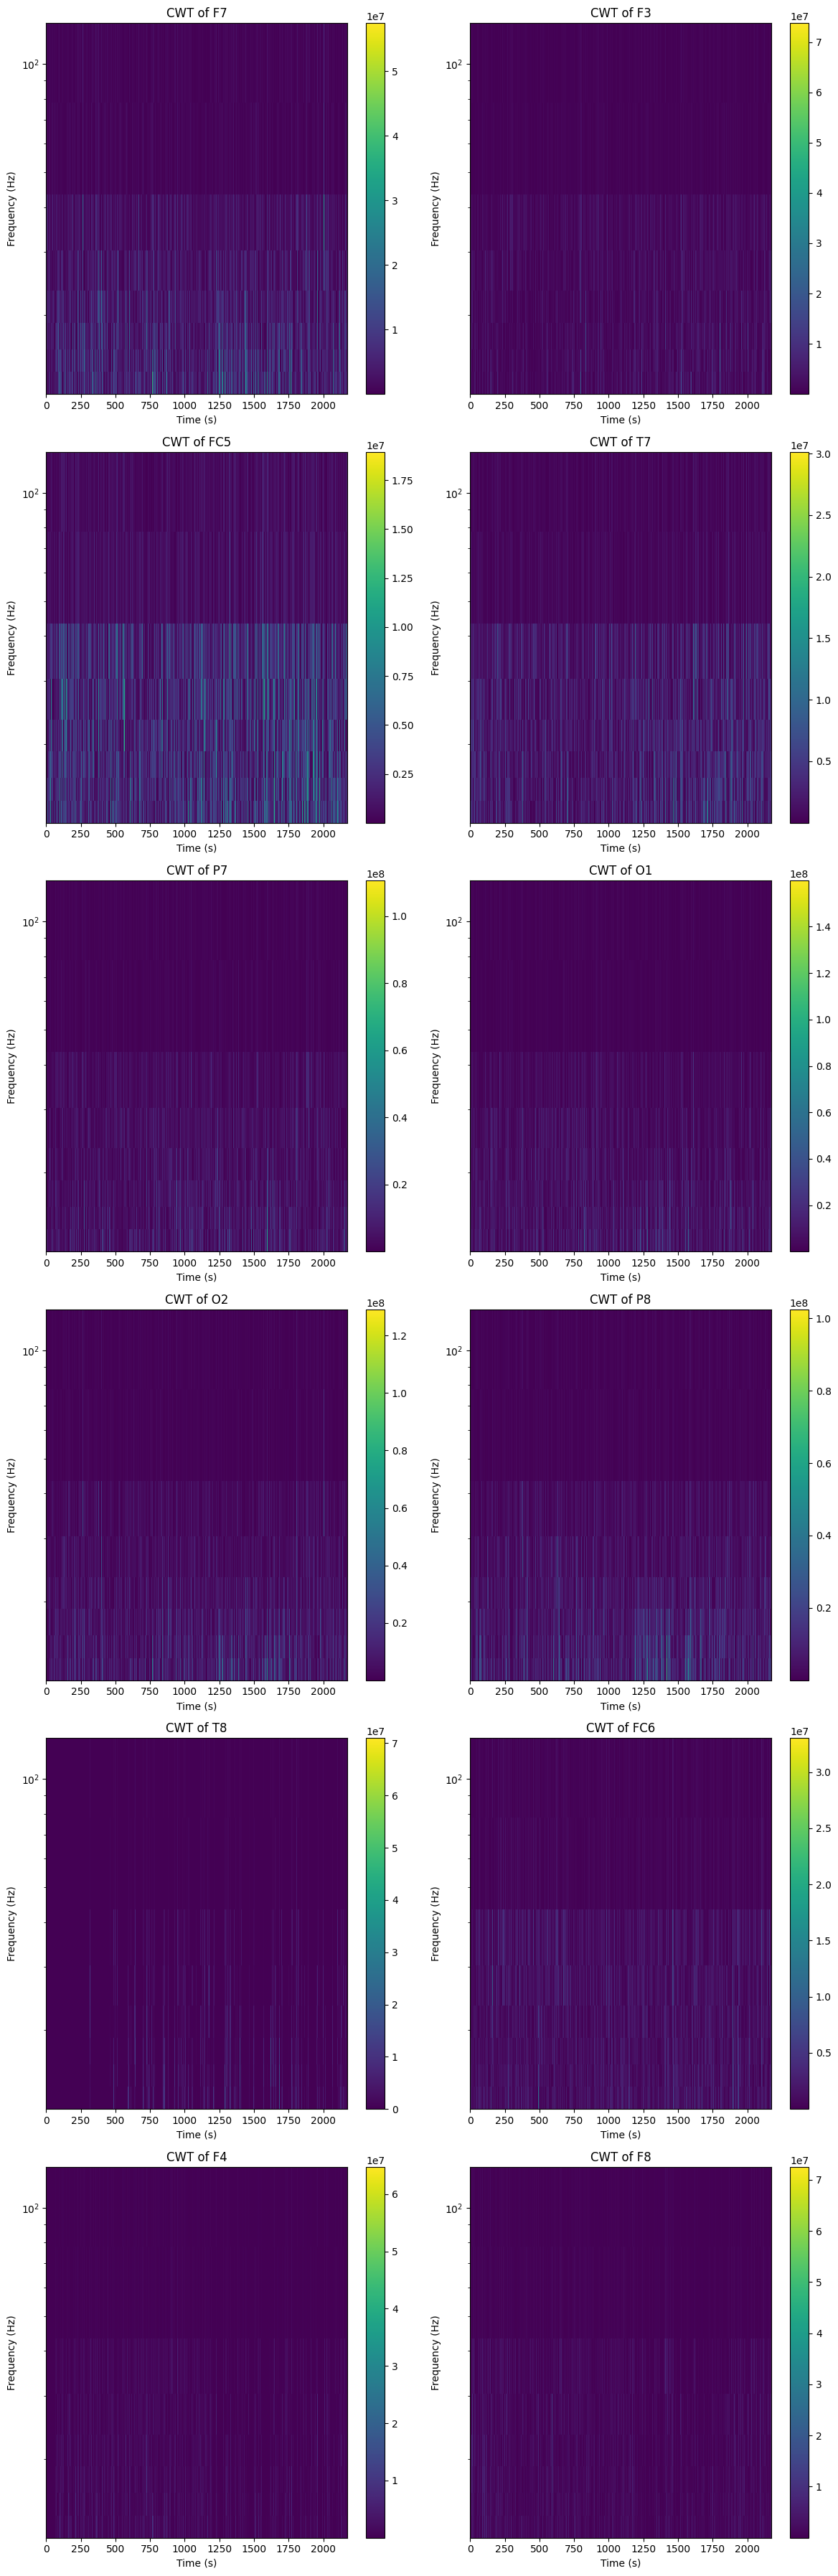

In [ ]:
scales = np.arange(1, 9)
plot_cwt_per_channel(features, scales)

The graph below shows the difference between CWT and Fourier Transform. While Fourier Transform change signal into Frequency domain, CWT change signal into Time-Frequency domain.

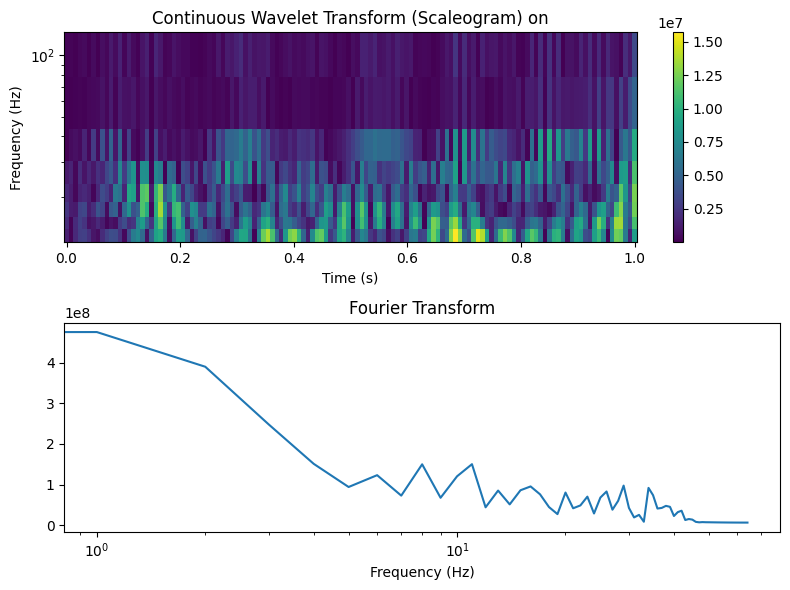

In [ ]:
signal = features.iloc[:128, 0]
plot_cwt_and_fft(signal)

### Classification by using CWT

Before making features and combined with FFT, we will use the CWT features to classify to evaluate this method. In this project, we use Morlet Wave as the Wave to transform and calculate component.

#### Transforming eeg dataset into cwt dataset

In [ ]:
# def make_epochs(X,num_rows, window_size=128, bridge=90):
#     """
#     Splits the input signal into overlapping or non-overlapping epochs.
#     """
#     epochs = []
#     for start in range(0, num_rows, bridge):
#         end = start + window_size
#         if end > num_rows:
#             end = num_rows
#         epochs.append(X[start:end])

#     print(f"Number of epochs: {len(epochs)}")
#     return epochs

# def process_epoch(epoch):
#      """
#     Processes a single epoch using the Continuous Wavelet Transform (CWT).
#     """
#     coeffs, freqs = pywt.cwt(epoch, scales, 'morl')
#     coeffs_abs = np.abs(coeffs)
#     coeffs_reduced = np.mean(coeffs_abs, axis=1, keepdims=True)
#     return coeffs_reduced

# def make_features(epochs):
#     """
#     Processes multiple epochs in parallel to extract features.
#     """
#     rows = Parallel(n_jobs=-1)(delayed(process_epoch)(epoch) for epoch in epochs)
#     return rows

In [ ]:
# # Initialize empty lists to store concatenated data
# all_X = []
# all_y = []

# # Test case with a small range
# for i in range(3,8):  # Adjust this range as needed
#         df = pd.read_csv(f'/kaggle/input/eeg-data/subject_{i}.csv')
#         X = df.drop(columns=['state','AF3','AF4'])

#         X_focused = X[0:76800]
#         X_unfocused = X[76800:153600]
#         X_drowsy = X[153600:]
#         print(f'subject_{i}')
#         focused = make_epochs(X_focused, X_focused.shape[0])
#         unfocused = make_epochs(X_unfocused, X_unfocused.shape[0])
#         drowsy = make_epochs(X_drowsy, X_drowsy.shape[0])

#         print(focused[0].shape)
#         # Process all epochs
#         focused_features = make_features(focused)
#         unfocused_features = make_features(unfocused)
#         drowsy_features = make_features(drowsy)

#         # Reshape the features with your existing logic
#         for j in range(len(focused)-1, 0, -1):
#             if focused_features[j].shape == (8, 1, 12):
#                 X_focused = np.stack(focused_features[:(j+1)])
#                 break

#         for j in range(len(unfocused)-1, 0, -1):
#             if unfocused_features[j].shape == (8, 1, 12):
#                 X_unfocused = np.stack(unfocused_features[:(j+1)])
#                 break

#         for j in range(len(drowsy)-1, 0, -1):
#             if drowsy_features[j].shape == (8, 1, 12):
#                 X_drowsy = np.stack(drowsy_features[:(j+1)])
#                 break

#         # Create corresponding labels
#         y_focused = np.zeros(len(X_focused))  # Label 0 for focused
#         y_unfocused = np.ones(len(X_unfocused))  # Label 1 for unfocused
#         y_drowsy = np.ones(len(X_drowsy)) * 2  # Label 2 for drowsy

#         # Combine features and labels for this subject
#         subject_X = np.concatenate([X_focused, X_unfocused, X_drowsy])
#         subject_y = np.concatenate([y_focused, y_unfocused, y_drowsy])

#         # Append to the overall lists
#         all_X.append(subject_X)
#         all_y.append(subject_y)

# # Concatenate data from all subjects
# final_X = np.concatenate(all_X)
# final_y = np.concatenate(all_y)

# # Verify shapes
# print("Final X shape:", final_X.shape)
# print("Final y shape:", final_y.shape)

# # Save to numpy files
# np.save('final_X_1.npy', final_X)
# np.save('final_y_1.npy', final_y)

# # Optional: Test loading the files
# loaded_X = np.load('final_X_1.npy')
# loaded_y = np.load('final_y_1.npy')

# print("Loaded X shape:", loaded_X.shape)
# print("Loaded y shape:", loaded_y.shape)

#### Data Loaded and Model Development

In [ ]:
X1=np.load('/kaggle/input/eeg-cwt-features/final_X_1.npy')
X2=np.load('/kaggle/input/eeg-cwt-features/final_X_2.npy')
X3=np.load('/kaggle/input/eeg-cwt-features/final_X_3.npy')
X4=np.load('/kaggle/input/eeg-cwt-features/final_X_4.npy')
X5=np.load('/kaggle/input/eeg-cwt-features/final_X_5.npy')

y1=np.load('/kaggle/input/eeg-cwt-features/final_y_1.npy')
y2=np.load('/kaggle/input/eeg-cwt-features/final_y_2.npy')
y3=np.load('/kaggle/input/eeg-cwt-features/final_y_3.npy')
y4=np.load('/kaggle/input/eeg-cwt-features/final_y_4.npy')
y5=np.load('/kaggle/input/eeg-cwt-features/final_y_5.npy')

In [ ]:
loaded_X=np.concatenate([X1,X2,X3,X4,X5])
loaded_y=np.concatenate([y1,y2,y3,y4,y5])

In [ ]:
# Process imbalance data by using down sampling
selected_X, selected_y = downsample_to_min_class(loaded_X, loaded_y)
print("Downsampled X shape:", selected_X.shape)
print("Downsampled y shape:", selected_y.shape)


unique, counts = np.unique(selected_y, return_counts=True)
print("Class distribution after downsampling:")
for class_label, count in zip(unique, counts):
    print(f"Label {class_label}: {count} samples")

Downsampled X shape: (61302, 8, 1, 12)
Downsampled y shape: (61302,)
Class distribution after downsampling:
Label 0.0: 20434 samples
Label 1.0: 20434 samples
Label 2.0: 20434 samples


In [ ]:
# Reshape data
X_reshaped = selected_X.reshape(selected_X.shape[0], -1)

In [ ]:
# Scale data before training
scaler=StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, selected_y, test_size=0.2, random_state=42)


Random Forest:
              precision    recall  f1-score   support

         0.0       0.63      0.71      0.67      4125
         1.0       0.60      0.55      0.58      4164
         2.0       0.69      0.65      0.67      3972

    accuracy                           0.64     12261
   macro avg       0.64      0.64      0.64     12261
weighted avg       0.64      0.64      0.64     12261

Micro-average AUC: 0.8208


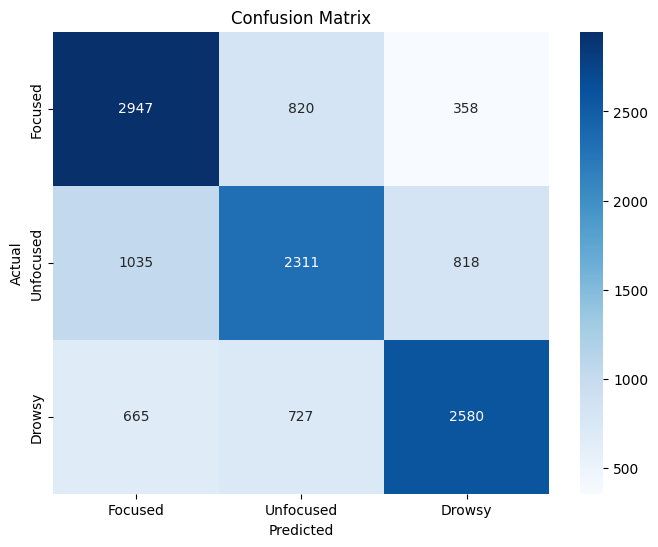

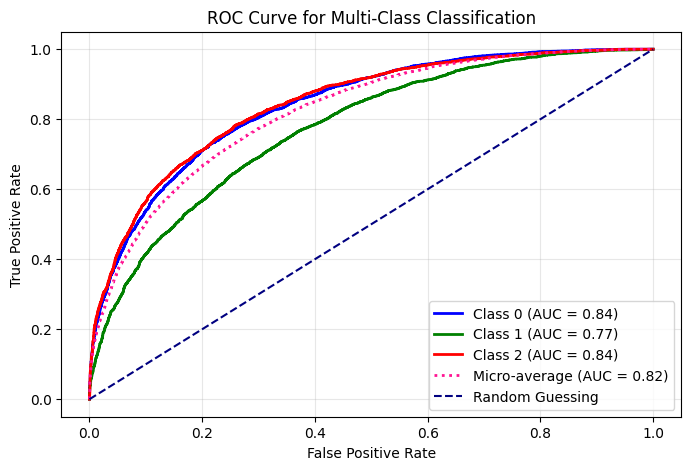

In [ ]:
# Using Random Forest to classification
rf =  RandomForestClassifier(
    max_depth=10,
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred=rf.predict(X_test)

print("Random Forest:")
print(classification_report(y_test,rf_pred))

y_score =rf.predict_proba(X_test)
y_true_bin = label_binarize(y_test, classes=list(range(3)))
micro_auc = roc_auc_score(y_true_bin, y_score, average="micro")
print(f"Micro-average AUC: {micro_auc:.4f}")

cm = confusion_matrix(y_test, rf_pred)
plot_confusion_matrix(cm=cm, labels=['Focused', 'Unfocused', 'Drowsy'])

plot_multiclass_roc(y_test, y_score, n_classes=3)

K-Nearest Neighbour:
              precision    recall  f1-score   support

         0.0       0.67      0.72      0.69      4125
         1.0       0.61      0.60      0.61      4164
         2.0       0.71      0.67      0.69      3972

    accuracy                           0.66     12261
   macro avg       0.66      0.66      0.66     12261
weighted avg       0.66      0.66      0.66     12261

Micro-average AUC: 0.8395


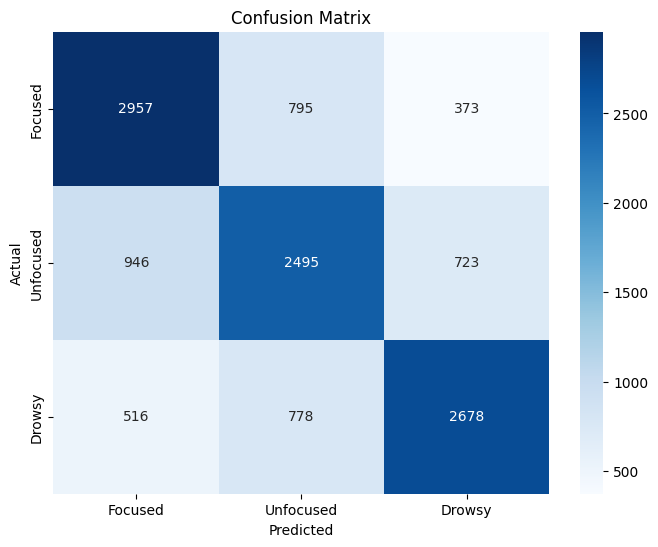

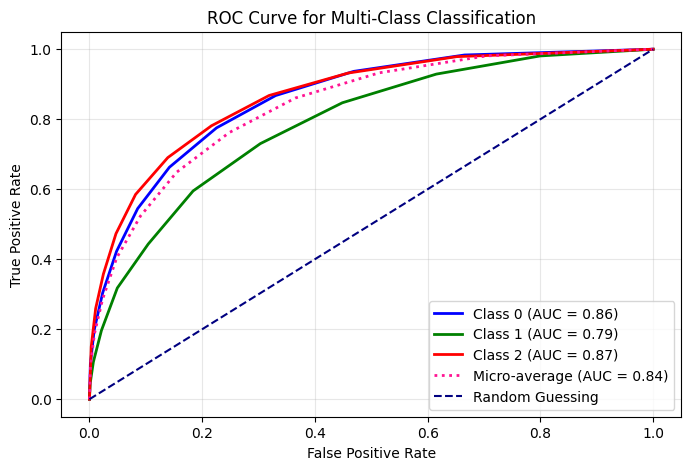

In [ ]:
# Using K-Nearest Neighbors to classification
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=10,
    weights='uniform',
    algorithm='auto'
)
knn.fit(X_train, y_train)
knn_pred=knn.predict(X_test)

print("K-Nearest Neighbour:")
print(classification_report(y_test,knn_pred))

y_score =knn.predict_proba(X_test)
y_true_bin = label_binarize(y_test, classes=list(range(3)))
micro_auc = roc_auc_score(y_true_bin, y_score, average="micro")
print(f"Micro-average AUC: {micro_auc:.4f}")

cm = confusion_matrix(y_test, knn_pred)
plot_confusion_matrix(cm=cm, labels=['Focused', 'Unfocused', 'Drowsy'])

plot_multiclass_roc(y_test, y_score, n_classes=3)

As can be seen, using only CWT features will not give good results. At the same time, distinguishing label 1 (Unfocused) from the other 2 labels is difficult because this state is an intermediate state, easier to confuse than the other 2 states.

## Adding CWT features into FFT dataset

### Tranforming EEG data and add features (included CWT features)

In [ ]:
# def calculate_cwt(samples, scales=np.arange(1,9), wavelet='morl'):
#     """
#     Calculate the Continuous Wavelet Transform (CWT) for a given signal.
#     Parameters:
#     - samples (array-like): The 1D input signal for which the CWT is computed.
#     - scales (array-like, optional): An array of scales to use for the wavelet transform.
#       - Default is np.arange(1, 9), which corresponds to scales 1 through 8.
#       - Smaller scales correspond to higher frequencies, and larger scales correspond to lower frequencies.
#     - wavelet (str, optional): The type of wavelet to use for the transform.
#       - Default is 'morl', which is the Morlet wavelet, commonly used in signal processing.
#     """
#     coeffs, freqs = pywt.cwt(samples, scales, wavelet)
#     coeffs_abs = np.abs(coeffs)
#     return coeffs_abs

# def make_frames_2(df, frame_duration, overlap,Fs = 128.0):
#     '''
#     in: dataframe or array with all channels, frame duration in seconds
#     out: array of theta, alpha, beta averages for each probe for each time step
#         shape: (n-frames, m-probes, k-brainwave bands)
#     '''
#     frame_length = int(Fs * frame_duration)
#     frames = []
#     steps = make_steps(len(df), frame_duration, overlap)
#     frq = None

#     for step_idx, step in enumerate(steps):
#         frame = []
#         for channel_idx, channel in enumerate(df.columns):
#             snippet = np.array(df.loc[step[0]:step[1]-1, channel])
#             f, Y = get_fft(snippet)
#             if frq is not None:
#                 frq = np.concatenate((frq, f), axis=0)
#             else:
#                 frq = f

#             #Split into signal bands
#             alpha, beta, gamma, theta, delta = waves_averages(f, Y)
#             frame.extend([alpha, beta, theta, delta])

#             # Statistic features
#             mean = np.mean(snippet)
#             variance = np.var(snippet)
#             std = np.std(snippet)
#             energy = np.sum(snippet**2)
#             skewness = skew(snippet)
#             excess_kurtosis = kurtosis(snippet)
#             frame.extend([mean,variance, std, energy, skewness, excess_kurtosis])

#             #Spectral features
#             psd = Y**2
#             psd_mean=np.mean(psd)
#             psd_norm = psd/np.sum(psd)
#             entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
#             frame.extend([psd_mean, entropy])

#             #Time-Frequency features
#             cwtmatr = calculate_cwt(snippet)
#             cwt_means = cwtmatr.mean(axis=1)
#             frame.extend(cwt_means)

#         frames.append(frame)

#     feature_columns = []
#     for channel in df.columns:
#         feature_columns.extend([
#             f'{channel}_alpha', f'{channel}_beta', f'{channel}_theta',
#             f'{channel}_delta', f'{channel}_mean', f'{channel}_variance',
#             f'{channel}_std', f'{channel}_energy', f'{channel}_skewness',
#             f'{channel}_kurtosis', f'{channel}_psd', f'{channel}_entropy'
#         ])
#         for i in range(1, 9):
#             feature_columns.append(f'{channel}_cwt_scale_{i}')
#     feature_df = pd.DataFrame(frames, columns=feature_columns)
#     return feature_df, frq

In [ ]:
# all_data=[]
# for i in range (17,21):
#         df=pd.read_csv(f'/kaggle/input/eeg-data/subject_{i}.csv')
#         print(f'subject_{i}')
#         df=df.drop(columns=['AF3','AF4'])
#         state_encode = {
#                 1: 0,
#                 2: 1,
#                 0: 2
#             }
#         df['state']=df['state'].map(state_encode)

#         df_focused = df[df['state'] == 0]
#         df_unfocused = df[df['state'] == 1].reset_index(drop=True)
#         df_drowsy = df[df['state'] == 2].reset_index(drop=True)

#         focused,focused_frq=make_frames_2(df_focused.drop(columns=['state']),1,0.3)
#         unfocused, unfocused_frq=make_frames_2(df_unfocused.drop(columns=['state']),1,0.3)
#         drowsy, drowsy_frq=make_frames_2(df_drowsy.drop(columns=['state']),1,0.3)

#         focused["state"] = 0
#         unfocused["state"] = 1
#         drowsy["state"] = 2
#         print('Length focused:',len(focused))
#         print('Length unfocused: ',len(unfocused))
#         print('Length drowsy: ',len(drowsy))
#         df_fft = pd.concat([focused, unfocused, drowsy])
#         all_data.append(df_fft)

# big_dataset = pd.concat(all_data, ignore_index=True)

# print('Length full dataset: ',len(big_dataset))
# big_data.to_csv('X_3.csv')

### Loading Data and Developing Model

As we know, the dataset is imbalance, so we still use down sampling to make it balance. Then we scale, split into train and test set and load into model

In [ ]:
p1=pd.read_csv('/kaggle/input/fft-features/Person_1.csv')
p2=pd.read_csv('/kaggle/input/fft-features/Person_2.csv')
p3=pd.read_csv('/kaggle/input/fft-features/Person_3.csv')
p4=pd.read_csv('/kaggle/input/fft-features/Person_4.csv')
p5=pd.read_csv('/kaggle/input/fft-features/Person_5.csv')

dataset=pd.concat([p1,p2,p3,p4,p5], ignore_index=True)
dataset.drop(columns=['Unnamed: 0'],inplace=True)

In [ ]:
subject_X=dataset.drop(columns=['state'])
subject_y=dataset['state']

In [ ]:
print("Original class distribution:", Counter(subject_y))

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(subject_X, subject_y)

print("Resampled class distribution:", Counter(y_resampled))

Original class distribution: Counter({2: 36183, 0: 20448, 1: 20387})
Resampled class distribution: Counter({0: 20387, 1: 20387, 2: 20387})


In [ ]:
scaler=StandardScaler()
scaled_X=scaler.fit_transform(X_resampled)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y_resampled, test_size=0.3, random_state=42)

Decision Tree
              precision    recall  f1-score   support

           0       0.74      0.73      0.73      6101
           1       0.64      0.64      0.64      6096
           2       0.75      0.74      0.74      6152

    accuracy                           0.71     18349
   macro avg       0.71      0.71      0.71     18349
weighted avg       0.71      0.71      0.71     18349

Micro-average AUC: 0.7795


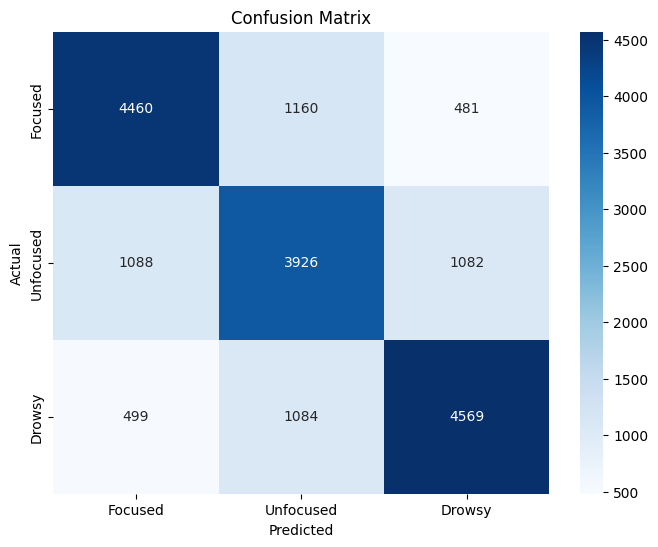

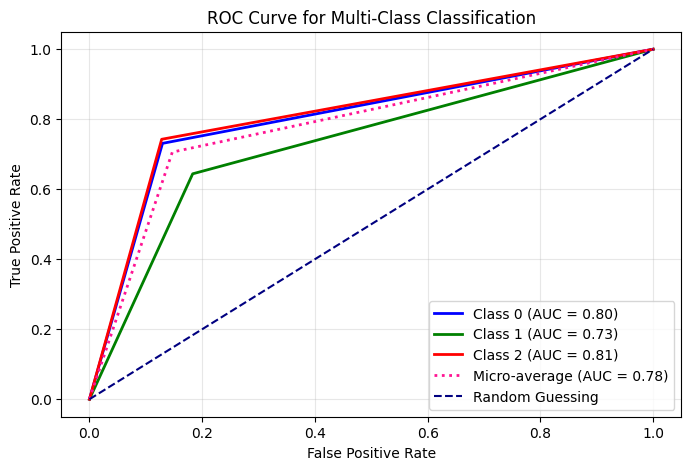

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=0)
dt_model.fit(X_train, y_train)

# Evaluate models
dt_preds = dt_model.predict(X_test)

print("Decision Tree")
print(classification_report(y_test, dt_preds))

y_score =dt_model.predict_proba(X_test)
y_true_bin = label_binarize(y_test, classes=list(range(3)))
micro_auc = roc_auc_score(y_true_bin, y_score, average="micro")
print(f"Micro-average AUC: {micro_auc:.4f}")

cm = confusion_matrix(y_test, dt_preds)
plot_confusion_matrix(cm=cm, labels=['Focused', 'Unfocused', 'Drowsy'])


plot_multiclass_roc(y_test, y_score, n_classes=3)

K-Neareast Neighbor
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      6101
           1       0.73      0.76      0.75      6096
           2       0.85      0.80      0.83      6152

    accuracy                           0.80     18349
   macro avg       0.80      0.80      0.80     18349
weighted avg       0.80      0.80      0.80     18349

Micro-average AUC: 0.9381


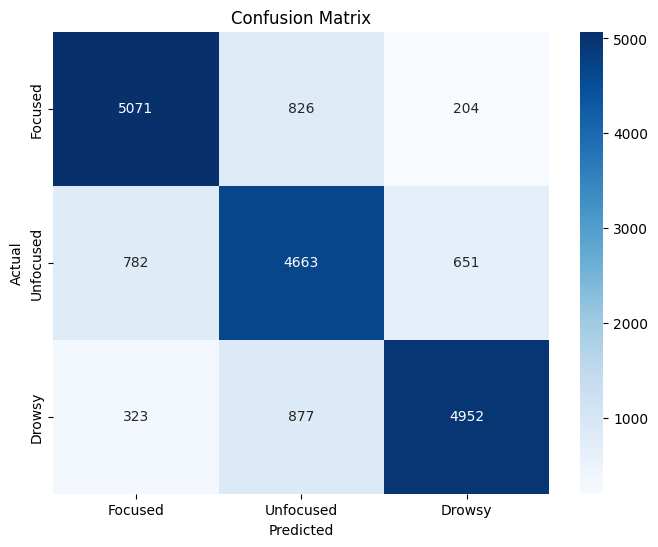

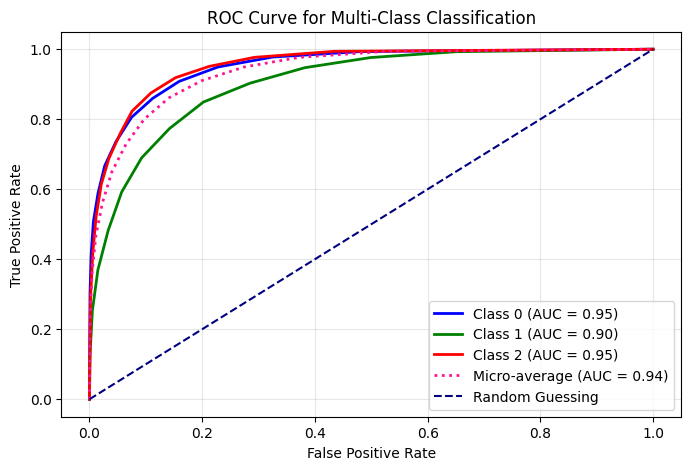

In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=12,
    weights='uniform',
    algorithm='auto'
)
knn_model.fit(X_train, y_train)

# Evaluate models
knn_preds = knn_model.predict(X_test)

print("K-Neareast Neighbor")
print(classification_report(y_test, knn_preds))

y_score =knn_model.predict_proba(X_test)
y_true_bin = label_binarize(y_test, classes=list(range(3)))
micro_auc = roc_auc_score(y_true_bin, y_score, average="micro")
print(f"Micro-average AUC: {micro_auc:.4f}")

cm = confusion_matrix(y_test, knn_preds)
plot_confusion_matrix(cm=cm, labels=['Focused', 'Unfocused', 'Drowsy'])


plot_multiclass_roc(y_test, y_score, n_classes=3)

As we can see, after adding CWT features, the robust of dataset improved so that accuracy, f1 and auc scores are all increased
* **Decision Tree**
  * accuracy: 68% -> 71%
  * f1 score: 68% -> 71%
  * auc score: 76% -> 78%

* **KNN**
  * accuracy: 75% -> 80%
  * f1 score: 76% -> 80%
  * auc score: 90% -> 94%

**Now we use stacking classifier to find the most suitable model with our data**

Stacking Classifier
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      6101
           1       0.78      0.79      0.78      6096
           2       0.87      0.87      0.87      6152

    accuracy                           0.84     18349
   macro avg       0.84      0.84      0.84     18349
weighted avg       0.84      0.84      0.84     18349

Micro-average AUC: 0.9554


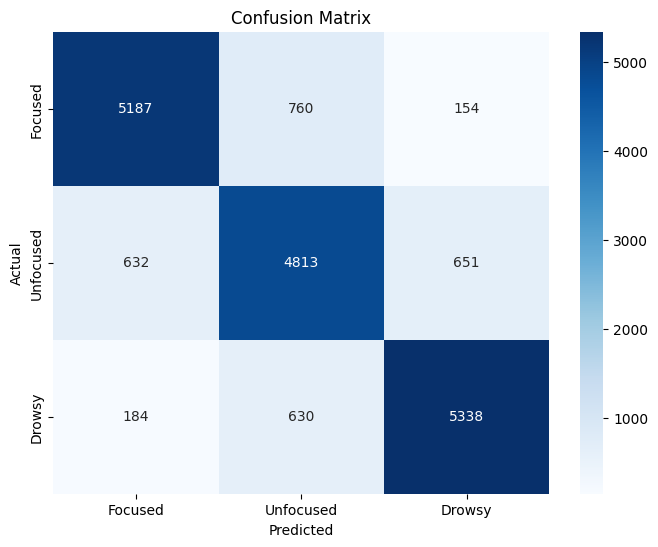

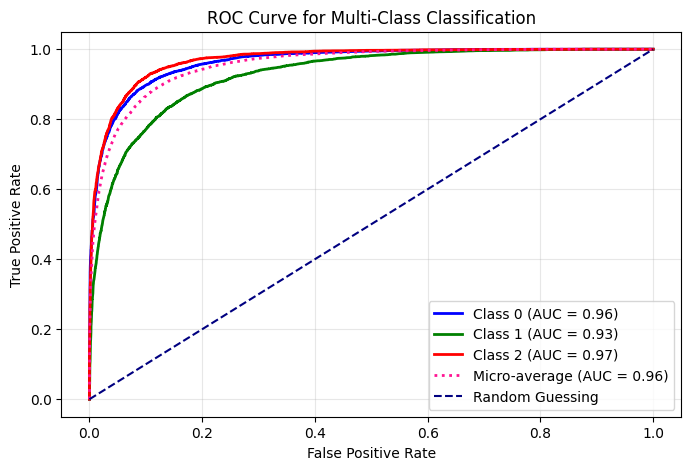

In [ ]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
    ('knn',  KNeighborsClassifier(
    n_neighbors=12,
    weights='uniform',
    algorithm='auto'
)),
    ('dt', DecisionTreeClassifier(random_state=0))
]
clf = StackingClassifier(
    estimators=estimators, final_estimator=LogisticRegression()
)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print("Stacking Classifier")
print(classification_report(y_test, preds))

y_score =clf.predict_proba(X_test)
y_true_bin = label_binarize(y_test, classes=list(range(3)))
micro_auc = roc_auc_score(y_true_bin, y_score, average="micro")
print(f"Micro-average AUC: {micro_auc:.4f}")

cm = confusion_matrix(y_test, preds)
plot_confusion_matrix(cm=cm, labels=['Focused', 'Unfocused', 'Drowsy'])


plot_multiclass_roc(y_test, y_score, n_classes=3)

## Conclusion

* Fourier Transform is a way to process signal data when this method can transform data into frequency domain, which is easier to process
* Continuous Wavelet Transform is not only a way to transform data, it can also be used to make features for signal data to make data more robust
* Applying Signal Bands, Statistic and Continuous Wavelet Transform is a good way to process EEG data
* Using Machine Learning make good perfomance when classify EEG data into 3 states: focused, unfocused and drowsy